# Hands-on 2 — From a density field to the cosmic web

Displace H1's field, watch a web appear, classify it, and find out how much of
it Zel'dovich had no business describing.

| # | step | ~min |
|---|---|---|
| 1 | rebuild the field from CAMB | 10 |
| 2 | the Zel'dovich displacement | 12 |
| 3 | project a slab — the web appears | 15 |
| 4 | classify it, and check the approximation | 16 |
| 5 | colour the slab | 10 |
| 6 | second order: 2LPT | 15 |
| 7 | benchmark against FlowPM | 10 |

Cells marked `# TODO` are yours. The cell below each one holds the answer and
is collapsed — expand it if you want it. Everything runs either way.

#### Cosmology, grid, and the linear spectrum

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Om, Ob, h, ns, sigma8, Tcmb = 0.31, 0.048, 0.676, 0.965, 0.81, 2.7255
N, L, SEED = 128, 250.0, 1234
k_f, k_Nyq = 2*np.pi/L, np.pi*N/L

try:
    import camb
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "camb"], check=False)
    try:
        import camb
    except ImportError:
        camb = None


def pk_from_camb():
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=100*h, ombh2=Ob*h*h, omch2=(Om - Ob)*h*h,
                       mnu=0.0, omk=0, num_massive_neutrinos=0)
    pars.InitPower.set_params(ns=ns, As=2.1e-9)
    pars.set_matter_power(redshifts=[0.0], kmax=60.0)
    pars.NonLinear = camb.model.NonLinear_none
    kk, _, pp = camb.get_results(pars).get_matter_power_spectrum(
        minkh=1e-4, maxkh=50.0, npoints=1024)
    return kk, pp[0]


def sigma_R(k, P, R=8.0):
    x = k*R
    W = 3*(np.sin(x) - x*np.cos(x))/x**3
    return np.sqrt(np.trapz(k**3*P*W**2/(2*np.pi**2), np.log(k)))


if camb is not None:
    ktab, ptab = pk_from_camb()
    source = "computed with CAMB"
else:
    import urllib.request
    url = ("https://raw.githubusercontent.com/MinhMPA/EFT-with-FFT/"
           "master/notebooks/pk_lin_fiducial.txt")
    try:
        tab = np.loadtxt("pk_lin_fiducial.txt")
    except OSError:
        urllib.request.urlretrieve(url, "pk_lin_fiducial.txt")
        tab = np.loadtxt("pk_lin_fiducial.txt")
    ktab, ptab = tab[:, 0], tab[:, 1]
    source = "from the shipped CAMB table"

ptab = ptab*(sigma8/sigma_R(ktab, ptab))**2      # normalise to sigma_8 = 0.81
pk_lin = lambda q: np.exp(np.interp(np.log(q), np.log(ktab), np.log(ptab)))
print(f"P_L(k) {source};  sigma_8 = {sigma_R(ktab, ptab):.4f}")

P_L(k) computed with CAMB;  sigma_8 = 0.8100


#### The same field H1 drew

Same seed, same box, same recipe — so this is H1's field, rebuilt rather than
loaded. Nothing you did in H1 needs to have worked.

In [2]:
kx = np.fft.fftfreq(N, d=1.0/N)*k_f
kz = np.fft.rfftfreq(N, d=1.0/N)*k_f
KX, KY, KZ = np.meshgrid(kx, kx, kz, indexing="ij")
K2 = KX**2 + KY**2 + KZ**2
K2[0, 0, 0] = 1.0

P_grid = pk_lin(np.sqrt(K2).ravel()).reshape(K2.shape)
P_grid[0, 0, 0] = 0.0

rng     = np.random.default_rng(SEED)
delta_k = np.fft.rfftn(rng.standard_normal((N, N, N)))*np.sqrt(P_grid*N**3/L**3)
delta_k[0, 0, 0] = 0.0
delta_x = np.fft.irfftn(delta_k, s=(N, N, N))

print(f"rms delta = {np.std(delta_x):.4f}")     # quiz: H1 got 2.516 with Eisenstein & Hu.
                                                #       Why is this one different?
assert 2.50 < np.std(delta_x) < 2.56, f"expected ~2.53, got {np.std(delta_x):.4f}"

rms delta = 2.5305


#### Growth factors

`Ψ⁽¹⁾ ∝ D₁` and `Ψ⁽²⁾ ∝ D₁²`, so one set of FFTs serves both epochs.

In [3]:
from scipy.integrate import quad          # only for the growth integral


def D1(z):
    """Linear growth, normalised to D1(0) = 1."""
    def integrand(a):
        return 1.0/(a*np.sqrt(Om/a**3 + (1 - Om)))**3
    def D(a):
        E = np.sqrt(Om/a**3 + (1 - Om))
        return 2.5*Om*E*quad(integrand, 1e-8, a, limit=200)[0]
    return D(1.0/(1 + z))/D(1.0)


for z in (49, 9, 1, 0):
    print(f"  z = {z:3d}   D1 = {D1(z):.4f}")

  z =  49   D1 = 0.0255
  z =   9   D1 = 0.1274
  z =   1   D1 = 0.6084
  z =   0   D1 = 1.0000


## Step 2 — The Zel'dovich displacement

Notes §2.2: every particle starts on a grid point $\boldsymbol{q}$ and moves to

$$\boldsymbol{x} = \boldsymbol{q} + D_1(z)\,\boldsymbol{\Psi}^{(1)}(\boldsymbol{q}),
\qquad \boldsymbol{\Psi}^{(1)}(\boldsymbol{k}) = \frac{i\boldsymbol{k}}{k^2}\,\delta(\boldsymbol{k}).$$

That is the unique curl-free field with $\nabla\cdot\boldsymbol{\Psi}^{(1)} = -\delta$,
which is what the checkpoint tests.

In [4]:
# TODO: Psi^(1)(k) = i k / k^2 * delta(k), for each of the three axes.
# Watch the sign: getting it backwards makes matter flow OUT of overdensities,
# and the rms will not tell you.
psi1_k = [...,  ...,  ...]

if not any(p is ... for p in psi1_k):   # skips quietly until you fill the dots
    psi1 = [np.fft.irfftn(p, s=(N, N, N)) for p in psi1_k]

In [5]:
#@title Solution — Psi^(1)
psi1_k = [1j*Ki/K2*delta_k for Ki in (KX, KY, KZ)]
psi1   = [np.fft.irfftn(p, s=(N, N, N)) for p in psi1_k]

In [6]:
# --- checkpoint: div Psi = -delta ---------------------------------------
F = np.fft.rfftn
div = np.fft.irfftn(1j*(KX*F(psi1[0]) + KY*F(psi1[1]) + KZ*F(psi1[2])), s=(N, N, N))
err = np.abs(div + delta_x).max()/np.abs(delta_x).max()

print(f"max |div.Psi + delta| / max|delta| = {err:.4f}")
print(f"rms Psi per axis at z=0            = "
      f"{[round(float(np.std(p)), 3) for p in psi1]}")

assert err < 0.05, f"div.Psi should equal -delta; got {err:.3f}"

max |div.Psi + delta| / max|delta| = 0.0278
rms Psi per axis at z=0            = [5.203, 4.828, 6.091]


The residual is **0.028**, not machine zero, and that is the **Nyquist plane**:
for even $N$ the mode at $k_{\rm Nyq}$ appears once with an ambiguous sign, so
$ik$ is not exactly antisymmetric there.

Note the three axes give **5.20, 4.83, 6.09** — a ±12% spread on identical
correct code, because $\Psi$ is dominated by the few longest modes the box holds.

#### What a finite box costs you

In [7]:
kk = np.logspace(-5, np.log10(50), 4000)
allk = np.sqrt(np.trapz(pk_lin(kk), kk)/(6*np.pi**2))
kb   = np.logspace(np.log10(k_f), np.log10(k_Nyq), 4000)
box  = np.sqrt(np.trapz(pk_lin(kb), kb)/(6*np.pi**2))
below = np.trapz(pk_lin(kk[kk < k_f]), kk[kk < k_f])/np.trapz(pk_lin(kk), kk)
below2 = (np.trapz(kk[kk < k_f]**2*pk_lin(kk[kk < k_f]), kk[kk < k_f])
          / np.trapz(kk**2*pk_lin(kk), kk))

print(f"rms Psi_x   realized            {np.std(psi1[0]):.3f} Mpc/h")
print(f"            continuum, all k    {allk:.3f}   -> you are {100*(1-np.std(psi1[0])/allk):.0f}% LOW")
print(f"            continuum, k_f..kNy {box:.3f}   -> you are {100*(np.std(psi1[0])/box-1):.0f}% HIGH")
print(f"\nfraction of int dk P     below k_f: {100*below:5.1f}%")
print(f"fraction of int dk k^2 P below k_f: {100*below2:5.2f}%")
# quiz: Psi = delta/k, so the displacement integral has no k-weighting and the
#       density integral has k^2. Which of the two numbers above explains the 10%?

rms Psi_x   realized            5.203 Mpc/h
            continuum, all k    5.833   -> you are 11% LOW
            continuum, k_f..kNy 5.039   -> you are 3% HIGH

fraction of int dk P     below k_f:  24.1%
fraction of int dk k^2 P below k_f:  0.01%


$\langle\Psi_x^2\rangle = \frac{1}{6\pi^2}\int{\rm d}k\,P(k)$ has **no
$k$-weighting**; $\langle\delta^2\rangle$ carries $k^2$. So the box throws away
**24%** of what makes displacements and **0.01%** of what makes density
contrast. Displacement is the quantity that notices a finite box.

## Step 3 — Project a slab

Every particle starts on the grid at $\boldsymbol{q}$ and moves to
$\boldsymbol{x} = \boldsymbol{q} + D_1(z)\,\boldsymbol{\Psi}^{(1)}(\boldsymbol{q})$.
Below, that displacement is applied at two epochs — $z=49$, close to the
initial conditions, and $z=0$, today — and a thin slab of each is projected
onto the plane.

In [8]:
q = (np.arange(N) + 0.5)*(L/N)
Q = np.meshgrid(q, q, q, indexing="ij")

pos49 = [(Q[i] + D1(49)*psi1[i]).ravel() % L for i in range(3)]
pos0  = [(Q[i] + D1(0) *psi1[i]).ravel() % L for i in range(3)]

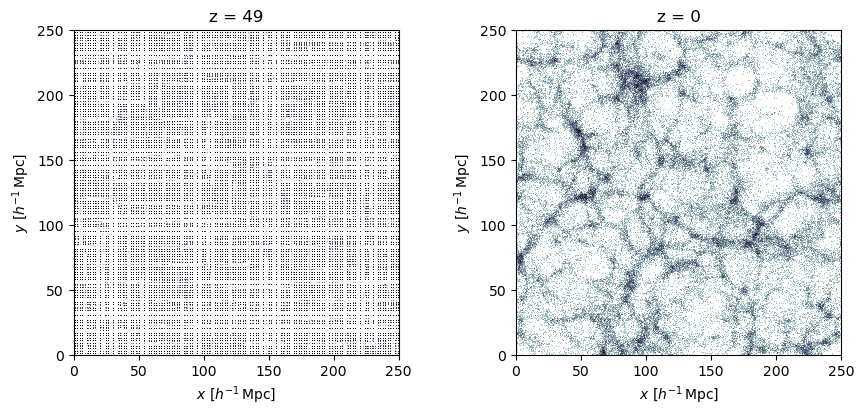

In [9]:
TH = 15.0     # h^-1 Mpc slab thickness
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
for a, pos, z in zip(ax, (pos49, pos0), (49, 0)):
    sel = pos[2] < TH
    Hc, _, _ = np.histogram2d(pos[0][sel], pos[1][sel], bins=400, range=[[0, L], [0, L]])
    a.imshow(np.log10(Hc.T + 1), origin="lower", extent=[0, L, 0, L],
             cmap="bone_r", interpolation="nearest")
    a.set_title(f"z = {z}")
    a.set_xlabel(r"$x\ [h^{-1}\,{\rm Mpc}]$")
    a.set_ylabel(r"$y\ [h^{-1}\,{\rm Mpc}]$")
plt.tight_layout()
plt.show()

# quiz: the left panel looks like a faint grid, the right like a web.
#       rms displacement is 0.07 cells at z=49 and 2.8 cells at z=0.
#       What sets the scale of the pattern you see in each panel?

At $z=49$ the displacement is about a fifteenth of a cell, so the picture is
just the Lagrangian grid, barely perturbed. At $z=0$ the web has appeared —
sheets, filaments, knots — and step 4 asks what kind of place each particle
landed in.